### Simple Linear Regression From Scratch

In [6]:
import numpy as np


class SimpleLinearRegression:
    def __init__(self):
        self.slope = None
        self.intercept = None

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)

        x_mean = np.mean(X)
        y_mean = np.mean(y)

        numerator = np.sum((X - x_mean) * (y - y_mean))
        denominator = np.sum((X - x_mean) ** 2)

        self.slope = numerator / denominator
        self.intercept = y_mean - self.slope * x_mean

    def predict(self, X):
        X = np.array(X)
        return self.slope * X + self.intercept

    def score(self, X, y):
        y_pred = self.predict(X)

        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)

        return 1 - (ss_res / ss_tot)

#### Usage

### Train the Model

In [7]:
import pandas as pd
import numpy as np
# Load dataset
df = pd.read_csv("Salary_dataset.csv")

# Feature and Target
X = df["YearsExperience"].values
y = df["Salary"].values

# Create model
model = SimpleLinearRegression()

# Train
model.fit(X, y)

print(f"Slope: {model.slope:.2f}")
print(f"Intercept: {model.intercept:.2f}")

# Predictions
y_pred = model.predict(X)

# R² Score
r2 = model.score(X, y)
print(f"R² Score: {r2:.4f}")

Slope: 9449.96
Intercept: 24848.20
R² Score: 0.9570


### Predict Salary for New Experience

In [7]:
experience = [4.5, 6.0, 8.5]

predicted_salary = model.predict(experience)

for exp, salary in zip(experience, predicted_salary):
    print(f"Experience: {exp} years -> Predicted Salary: ₹{salary:,.0f}")

Experience: 4.5 years -> Predicted Salary: ₹67,373
Experience: 6.0 years -> Predicted Salary: ₹81,548
Experience: 8.5 years -> Predicted Salary: ₹105,173


### Visualize Regression Line

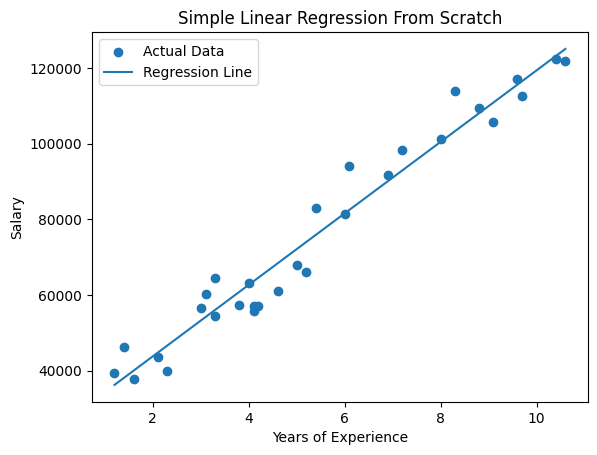

In [8]:
import matplotlib.pyplot as plt

plt.scatter(X, y, label="Actual Data")

plt.plot(
    X,
    model.predict(X),
    label="Regression Line"
)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Simple Linear Regression From Scratch")
plt.legend()
plt.show()